# Exploratory Data Analysis

Before building anything, understand the data. This notebook walks through the structure, statistics, and key patterns in the dataset. Run every cell and read the outputs carefully — your state space and reward function decisions should be informed by what you find here.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import load_prices, build_features

INTERVAL = '15m'   # change to '30m' or '15m' if you downloaded those
data = load_prices(INTERVAL)

ASSETS = ['asset_0', 'asset_1', 'asset_2']
COLORS = ['#2196F3', '#FF9800', '#4CAF50']

print(f'Shape  : {data.shape}')
print(f'From   : {data.index[0]}')
print(f'To     : {data.index[-1]}')
print(f'Columns: {list(data.columns)}')

Shape  : (279907, 16)
From   : 2018-01-01 00:14:59.999000
To     : 2025-12-31 00:14:59.999000
Columns: ['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 'cash']


In [2]:
data.head(5)

,asset_0_close,asset_0_high,asset_0_low,asset_0_volume,asset_0_taker_buy_ratio,asset_1_close,asset_1_high,asset_1_low,asset_1_volume,asset_1_taker_buy_ratio,asset_2_close,asset_2_high,asset_2_low,asset_2_volume,asset_2_taker_buy_ratio,cash
2018-01-01 00:14:59.999,55.946923,56.501538,55.608462,420.84730,0.500611,2.801567,2.849267,2.785767,11019.26,0.624723,71.348158,72.187632,70.526368,123.616013,0.511480,1.0
2018-01-01 00:29:59.999,55.808462,56.033846,55.386923,586.88558,0.599324,2.782567,2.816633,2.782567,17473.55,0.212946,71.163789,71.320368,70.536842,98.136430,0.485919,1.0
2018-01-01 00:44:59.999,55.644615,56.046923,55.603846,522.11912,0.570823,2.773333,2.791100,2.767967,9481.16,0.215882,70.896895,71.291421,70.789474,79.904037,0.547036,1.0
2018-01-01 00:59:59.999,55.970769,55.970769,55.576923,576.04900,0.720042,2.785300,2.791667,2.748667,11513.17,0.303251,71.205316,72.057211,70.789474,141.699719,0.521511,1.0
2018-01-01 01:14:59.999,55.741538,56.019231,55.615385,320.34994,0.380977,2.764100,2.786667,2.733333,5960.76,0.385434,70.766474,71.430211,70.538316,72.537533,0.472275,1.0


## 1. Price History

Prices are normalized to 100 at the start so all three assets are on the same scale.

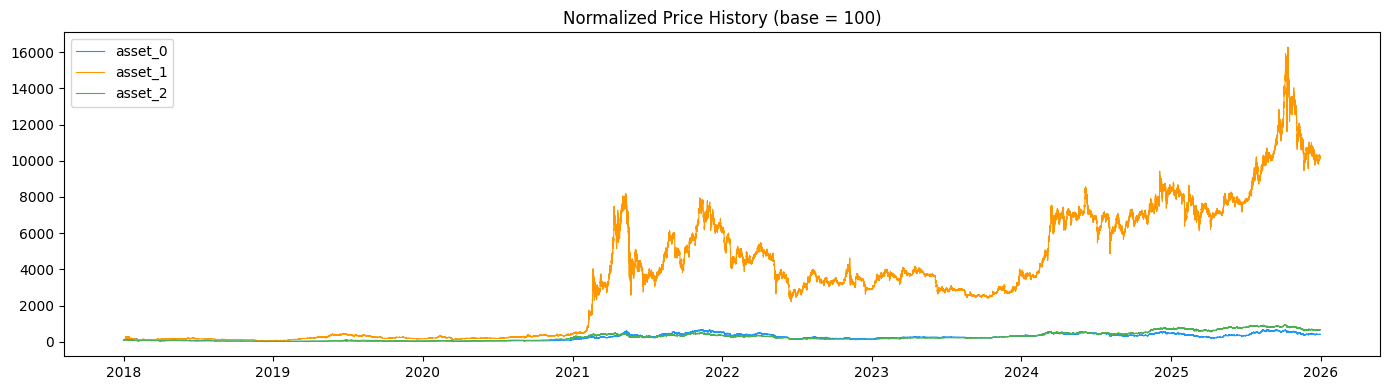


Total return over full period:
  asset_0: 308%
  asset_1: 10136%
  asset_2: 552%


In [3]:
closes = data[[f'{a}_close' for a in ASSETS]].rename(columns={f'{a}_close': a for a in ASSETS})
normalized = closes / closes.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 4))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(normalized.index, normalized[asset], label=asset, color=color, linewidth=0.8)
ax.set_title('Normalized Price History (base = 100)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('\nTotal return over full period:')
for asset in ASSETS:
    ret = (closes[asset].iloc[-1] / closes[asset].iloc[0] - 1) * 100
    print(f'  {asset}: {ret:.0f}%')

## 2. Return Distributions

Log-returns are what your agent ultimately works with. Notice the fat tails — large moves happen much more often than a normal distribution would predict.

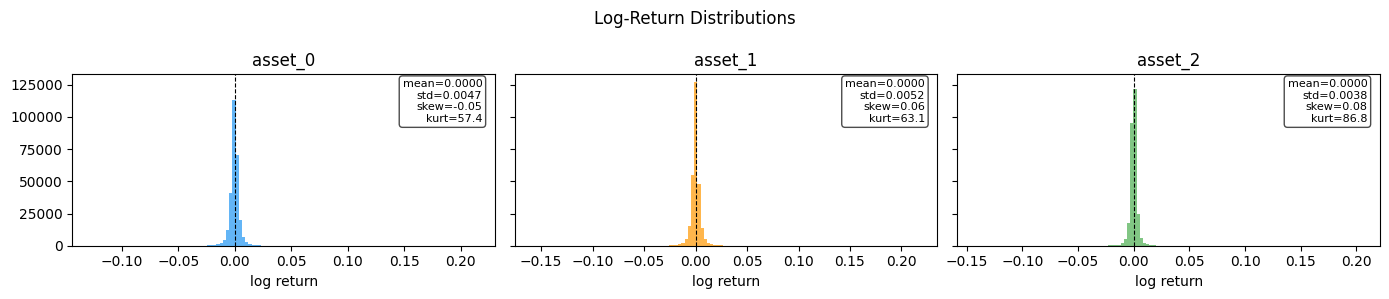

In [4]:
log_rets = np.log(closes / closes.shift(1)).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, asset, color in zip(axes, ASSETS, COLORS):
    r = log_rets[asset]
    ax.hist(r, bins=120, color=color, alpha=0.7, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(asset)
    ax.set_xlabel('log return')
    stats = f"mean={r.mean():.4f}\nstd={r.std():.4f}\nskew={r.skew():.2f}\nkurt={r.kurtosis():.1f}"
    ax.text(0.97, 0.97, stats, transform=ax.transAxes, va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.suptitle('Log-Return Distributions')
plt.tight_layout()
plt.show()

## 3. Rolling Volatility

Volatility is not constant — it clusters. Calm periods and turbulent periods alternate. This is a key challenge for your agent: what works in a low-volatility regime may fail in a high-volatility one.

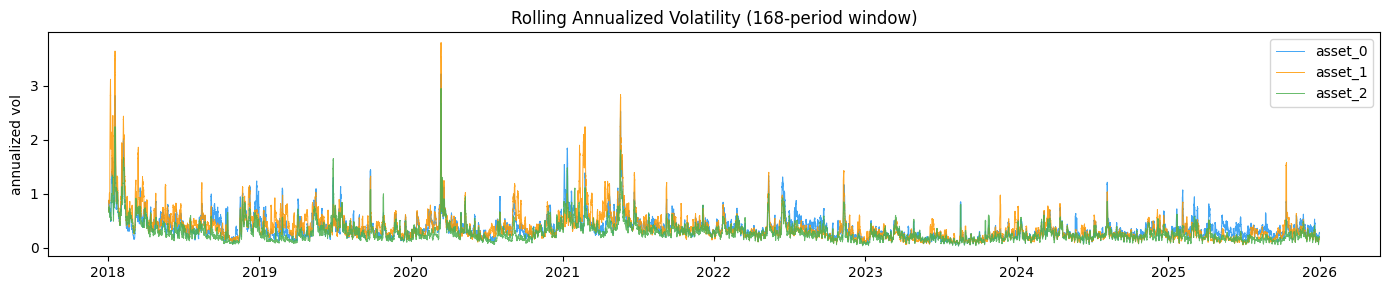

In [5]:
window = 24 * 7  # one week of hourly candles
vol = log_rets.rolling(window).std() * np.sqrt(24 * 365)  # annualized

fig, ax = plt.subplots(figsize=(14, 3))
for asset, color in zip(ASSETS, COLORS):
    ax.plot(vol.index, vol[asset], label=asset, color=color, linewidth=0.7, alpha=0.85)
ax.set_title(f'Rolling Annualized Volatility ({window}-period window)')
ax.set_ylabel('annualized vol')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 4. Correlation Between Assets

How correlated are the assets? High correlation means diversification offers less benefit. It also affects how your agent should think about portfolio construction.

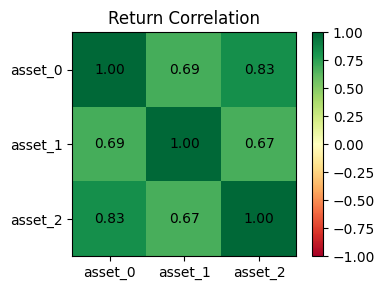

In [6]:
corr = log_rets.corr()

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(len(ASSETS))); ax.set_xticklabels(ASSETS)
ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(ASSETS)
for i in range(len(ASSETS)):
    for j in range(len(ASSETS)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Return Correlation')
plt.tight_layout()
plt.show()

## 5. Volume and Taker Buy Ratio

Volume spikes often precede or coincide with large price moves. The taker buy ratio (fraction of volume initiated by buyers) is a microstructure signal of short-term directional pressure.

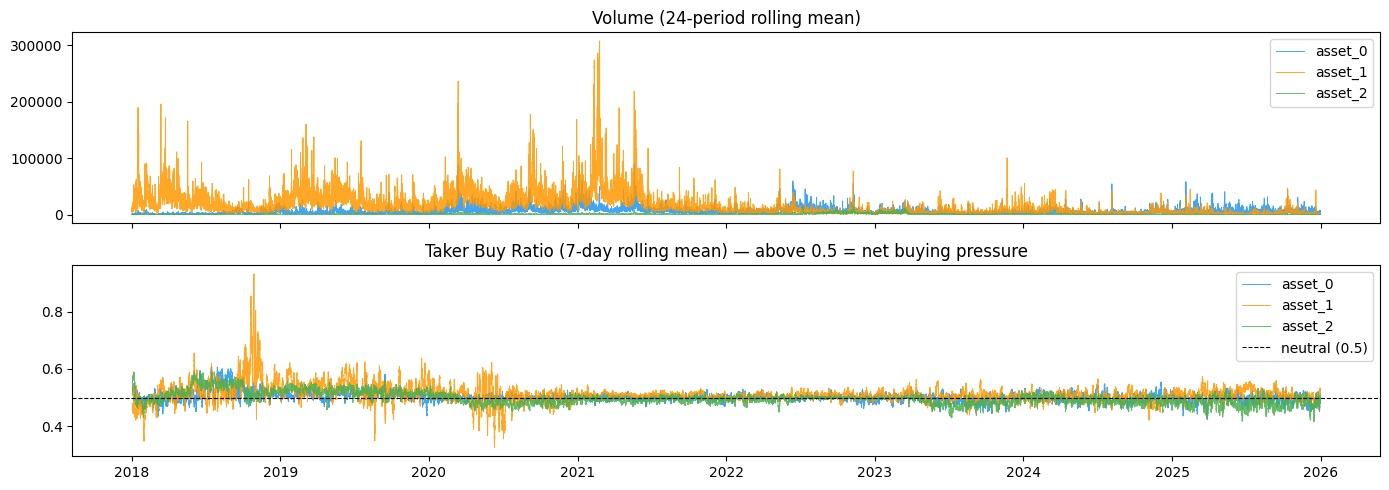

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# Volume (rolling mean to smooth)
for asset, color in zip(ASSETS, COLORS):
    vol_series = data[f'{asset}_volume'].rolling(24).mean()
    axes[0].plot(vol_series.index, vol_series, label=asset, color=color, linewidth=0.7, alpha=0.85)
axes[0].set_title('Volume (24-period rolling mean)')
axes[0].legend()

# Taker buy ratio
for asset, color in zip(ASSETS, COLORS):
    tbr = data[f'{asset}_taker_buy_ratio'].rolling(24 * 7).mean()
    axes[1].plot(tbr.index, tbr, label=asset, color=color, linewidth=0.7, alpha=0.85)
axes[1].axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='neutral (0.5)')
axes[1].set_title('Taker Buy Ratio (7-day rolling mean) — above 0.5 = net buying pressure')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 6. Drawdown Profile

What does the worst-case look like for each asset? This should calibrate your expectations for how bad things can get, and inform your reward function design.

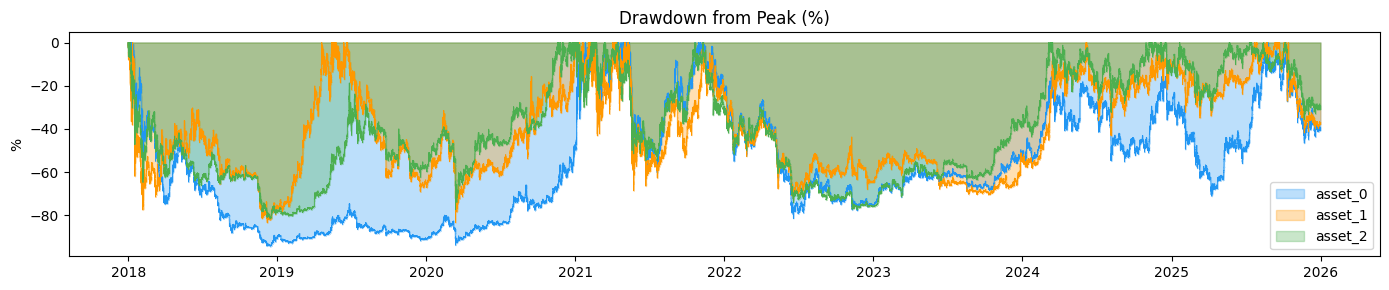

Max drawdown:
  asset_0: -94.3%
  asset_1: -83.4%
  asset_2: -81.6%


In [8]:
fig, ax = plt.subplots(figsize=(14, 3))
for asset, color in zip(ASSETS, COLORS):
    price = closes[asset]
    peak = price.cummax()
    dd = (price - peak) / peak * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.3, color=color, label=asset)
    ax.plot(dd.index, dd, color=color, linewidth=0.6)
ax.set_title('Drawdown from Peak (%)')
ax.set_ylabel('%')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

print('Max drawdown:')
for asset in ASSETS:
    price = closes[asset]
    peak = price.cummax()
    print(f'  {asset}: {((price - peak) / peak).min() * 100:.1f}%')

## Key Takeaways

Before moving to `agent.py`, make sure you can answer:

1. **Volatility is regime-dependent.** Your agent will train on some regimes and be evaluated on others. How should your state capture this?
2. **Assets are correlated but not identical.** Diversification has value, but not as much as with truly uncorrelated assets.
3. **Drawdowns are severe.** A naive hold strategy can lose 80%+. Your reward function needs to account for this.
4. **Volume and taker buy ratio carry information.** Whether to include them in your state is a design decision — justify it.
5. **The data is noisy.** Do not expect your agent to find a clean signal. Focus on robustness over peak performance.